# Experiment 5.2.1 — FF Multi-Tau Memory × Objective

Analysis-only notebook. It reads finalized artifacts produced by the multi-CPU experiment runner. It never trains models, launches Slurm, regenerates missing runs, or selects a condition using test BA.

Primary comparison: `SingleTau vs MultiTau` × `Endpoint CE vs Endpoint + Fixed250 auxiliary CE`. Final deployed readout is always hidden `Uend -> Linear -> logits`.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate writingRing repository root")


REPO_ROOT = find_repo_root()
ARTIFACT_ROOT = (
    REPO_ROOT
    / "notebooks"
    / "artifacts"
    / "experiment_5_2_1_ff_multitau_objectives"
    / "frozen_exp3_l2_ff_multitau_objectives_v1"
)
runs = pd.read_csv(ARTIFACT_ROOT / "runs.csv")
histories = pd.read_csv(ARTIFACT_ROOT / "histories.csv")
local_reference = pd.read_csv(ARTIFACT_ROOT / "local_reference.csv")
manifest = json.loads((ARTIFACT_ROOT / "manifest.json").read_text(encoding="utf-8"))

assert len(runs) == manifest["expected_runs"] == 20
assert set(runs["seed"]) == set(manifest["seeds"])
runs.head()


,memory_mode,objective,seed,tau_profile_ms,best_epoch,native_train_accuracy,native_train_balanced_accuracy,native_train_macro_f1,native_train_loss,native_train_endpoint_loss,...,hidden_whole_count_C,hidden_fixed250_ordered_val_ba,hidden_fixed250_ordered_test_ba,hidden_fixed250_ordered_C,hidden_relative10_ordered_val_ba,hidden_relative10_ordered_test_ba,hidden_relative10_ordered_C,hidden_uend_val_ba,hidden_uend_test_ba,hidden_uend_C
0,single_shift7,endpoint_ce,11,1992.177,18,0.903614,0.903237,0.902329,0.313062,0.313062,...,0.01,0.567629,0.602194,0.01,0.626263,0.649813,0.01,0.587205,0.597310,0.010
1,single_shift7,endpoint_ce,23,1992.177,24,0.939759,0.940498,0.940093,0.228655,0.228655,...,0.01,0.606307,0.553871,10.00,0.614310,0.608906,0.10,0.545052,0.592847,0.010
2,single_shift7,endpoint_ce,37,1992.177,83,0.982788,0.983684,0.983596,0.110788,0.110788,...,0.10,0.546411,0.471716,10.00,0.584337,0.615323,0.01,0.545340,0.549777,0.001
3,single_shift7,endpoint_ce,53,1992.177,98,0.982788,0.983377,0.983157,0.094751,0.094751,...,1.00,0.544354,0.612957,0.10,0.585865,0.622447,10.00,0.576641,0.554029,0.100
4,single_shift7,endpoint_ce,71,1992.177,66,0.960413,0.962454,0.961635,0.171213,0.171213,...,10.00,0.508796,0.572802,0.01,0.585528,0.664860,0.01,0.556193,0.585191,0.100


## Condition summary

Checkpoint selection is per-run validation-only. Test metrics below are descriptive evaluation of those already-selected checkpoints.


In [2]:
summary_metrics = [
    "native_val_balanced_accuracy",
    "native_test_balanced_accuracy",
    "hidden_uend_val_ba",
    "hidden_uend_test_ba",
    "hidden_fixed250_ordered_test_ba",
    "hidden_relative10_ordered_test_ba",
    "hidden_whole_count_test_ba",
]
condition_summary = (
    runs.groupby(["memory_mode", "objective"])[summary_metrics]
    .agg(["mean", "std"])
    .sort_values(("native_val_balanced_accuracy", "mean"), ascending=False)
)
condition_summary


native_val_balanced_accuracy            \
                                                               mean       std   
memory_mode   objective                                                         
multitau_4567 endpoint_ce                                  0.575583  0.012719   
              endpoint_fixed250_aux_ce                     0.571614  0.006509   
single_shift7 endpoint_ce                                  0.563492  0.017112   
              endpoint_fixed250_aux_ce                     0.552701  0.017785   

                                       native_test_balanced_accuracy  \
                                                                mean   
memory_mode   objective                                                
multitau_4567 endpoint_ce                                   0.562702   
              endpoint_fixed250_aux_ce                      0.560549   
single_shift7 endpoint_ce                                   0.514414   
              endpoint_fixed250_aux_ce                      0.522412   

                                                 hidden_uend_val_ba            \
                                             std               mean       std   
memory_mode   objective                                                         
multitau_4567 endpoint_ce               0.015539           0.561607  0.023062   
              endpoint_fixed250_aux_ce  0.015088           0.551258  0.019827   
single_shift7 endpoint_ce               0.030672           0.562086  0.019027   
              endpoint_fixed250_aux_ce  0.041083           0.556342  0.037958   

                                       hidden_uend_test_ba            \
                                                      mean       std   
memory_mode   objective                                                
multitau_4567 endpoint_ce                         0.565739  0.030391   
              endpoint_fixed250_aux_ce            0.554971  0.030402   
single_shift7 endpoint_ce                         0.575831  0.022320   
              endpoint_fixed250_aux_ce            0.552536  0.019094   

                                       hidden_fixed250_ordered_test_ba  \
                                                                  mean   
memory_mode   objective                                                  
multitau_4567 endpoint_ce                                     0.581884   
              endpoint_fixed250_aux_ce                        0.566619   
single_shift7 endpoint_ce                                     0.562708   
              endpoint_fixed250_aux_ce                        0.588738   

                                                  \
                                             std   
memory_mode   objective                            
multitau_4567 endpoint_ce               0.019786   
              endpoint_fixed250_aux_ce  0.033866   
single_shift7 endpoint_ce               0.055999   
              endpoint_fixed250_aux_ce  0.019298   

                                       hidden_relative10_ordered_test_ba  \
                                                                    mean   
memory_mode   objective                                                    
multitau_4567 endpoint_ce                                       0.623565   
              endpoint_fixed250_aux_ce                          0.620289   
single_shift7 endpoint_ce                                       0.632270   
              endpoint_fixed250_aux_ce                          0.641427   

                                                 hidden_whole_count_test_ba  \
                                             std                       mean   
memory_mode   objective                                                       
multitau_4567 endpoint_ce               0.040000                   0.510852   
              endpoint_fixed250_aux_ce  0.031682                   0.506989   
single_shift7 endpoint_ce               0.023976                   0.501930   
  

In [3]:
diagnostic_runs = runs.copy()
diagnostic_runs["head_utilization_gap"] = (
    diagnostic_runs["hidden_uend_test_ba"]
    - diagnostic_runs["native_test_balanced_accuracy"]
)
diagnostic_runs["trajectory_endpoint_gap"] = (
    diagnostic_runs["hidden_relative10_ordered_test_ba"]
    - diagnostic_runs["hidden_uend_test_ba"]
)
diagnostic_runs["local_fixed250_gap"] = np.nan

local_fixed = (
    local_reference[local_reference["probe_type"] == "local_fixed250_ordered"]
    .set_index("seed")["test_ba"]
)
diagnostic_runs["local_fixed250_gap"] = diagnostic_runs.apply(
    lambda row: local_fixed.loc[row["seed"]] - row["hidden_uend_test_ba"], axis=1
)

diagnostic_summary = (
    diagnostic_runs.groupby(["memory_mode", "objective"])[
        ["head_utilization_gap", "trajectory_endpoint_gap", "local_fixed250_gap"]
    ]
    .agg(["mean", "std"])
)
diagnostic_summary


head_utilization_gap            \
                                                       mean       std   
memory_mode   objective                                                 
multitau_4567 endpoint_ce                          0.003037  0.024567   
              endpoint_fixed250_aux_ce            -0.005578  0.027058   
single_shift7 endpoint_ce                          0.061416  0.038131   
              endpoint_fixed250_aux_ce             0.030123  0.056295   

                                       trajectory_endpoint_gap            \
                                                          mean       std   
memory_mode   objective                                                    
multitau_4567 endpoint_ce                             0.057826  0.048168   
              endpoint_fixed250_aux_ce                0.065318  0.036335   
single_shift7 endpoint_ce                             0.056439  0.024557   
              endpoint_fixed250_aux_ce                0.088891  0.035392   

                                       local_fixed250_gap            
                                                     mean       std  
memory_mode   objective                                              
multitau_4567 endpoint_ce                        0.059315  0.036689  
              endpoint_fixed250_aux_ce           0.070084  0.035145  
single_shift7 endpoint_ce                        0.049224  0.040914  
              endpoint_fixed250_aux_ce           0.072519  0.037027

## Paired factorial effects

All effects are paired by seed. `memory_effect` is MultiTau − SingleTau within the same objective. `objective_effect` is auxiliary objective − endpoint-only objective within the same memory mode. `interaction_effect` is the difference-of-differences.


In [4]:
def paired_memory_effect(frame, metric):
    wide = frame.pivot(index="seed", columns=["objective", "memory_mode"], values=metric)
    rows = []
    for objective in manifest["objectives"]:
        effect = wide[(objective, "multitau_4567")] - wide[(objective, "single_shift7")]
        rows.append({
            "objective": objective,
            "metric": metric,
            "mean": effect.mean(),
            "sd": effect.std(ddof=1),
            "positive_seeds": int((effect > 0).sum()),
        })
    return pd.DataFrame(rows)


def paired_objective_effect(frame, metric):
    wide = frame.pivot(index="seed", columns=["memory_mode", "objective"], values=metric)
    rows = []
    for memory_mode in manifest["memory_modes"]:
        effect = (
            wide[(memory_mode, "endpoint_fixed250_aux_ce")]
            - wide[(memory_mode, "endpoint_ce")]
        )
        rows.append({
            "memory_mode": memory_mode,
            "metric": metric,
            "mean": effect.mean(),
            "sd": effect.std(ddof=1),
            "positive_seeds": int((effect > 0).sum()),
        })
    return pd.DataFrame(rows)


def paired_interaction_effect(frame, metric):
    wide = frame.pivot(index="seed", columns=["memory_mode", "objective"], values=metric)
    memory_old = (
        wide[("multitau_4567", "endpoint_ce")]
        - wide[("single_shift7", "endpoint_ce")]
    )
    memory_new = (
        wide[("multitau_4567", "endpoint_fixed250_aux_ce")]
        - wide[("single_shift7", "endpoint_fixed250_aux_ce")]
    )
    interaction = memory_new - memory_old
    return pd.DataFrame({
        "seed": interaction.index,
        "metric": metric,
        "interaction_effect": interaction.values,
    })

factorial_metrics = [
    "native_val_balanced_accuracy",
    "native_test_balanced_accuracy",
    "hidden_uend_test_ba",
    "hidden_relative10_ordered_test_ba",
]
memory_effect = pd.concat(
    [paired_memory_effect(runs, metric) for metric in factorial_metrics], ignore_index=True
)
objective_effect = pd.concat(
    [paired_objective_effect(runs, metric) for metric in factorial_metrics], ignore_index=True
)
interaction_effect = pd.concat(
    [paired_interaction_effect(runs, metric) for metric in factorial_metrics], ignore_index=True
)
interaction_summary = interaction_effect.groupby("metric")["interaction_effect"].agg(["mean", "std"])

memory_effect, objective_effect, interaction_summary


(                  objective                             metric      mean  \
 0               endpoint_ce       native_val_balanced_accuracy  0.012091   
 1  endpoint_fixed250_aux_ce       native_val_balanced_accuracy  0.018913   
 2               endpoint_ce      native_test_balanced_accuracy  0.048288   
 3  endpoint_fixed250_aux_ce      native_test_balanced_accuracy  0.038136   
 4               endpoint_ce                hidden_uend_test_ba -0.010091   
 5  endpoint_fixed250_aux_ce                hidden_uend_test_ba  0.002435   
 6               endpoint_ce  hidden_relative10_ordered_test_ba -0.008704   
 7  endpoint_fixed250_aux_ce  hidden_relative10_ordered_test_ba -0.021138   
 
          sd  positive_seeds  
 0  0.009671               4  
 1  0.015431               5  
 2  0.020721               5  
 3  0.043635               4  
 4  0.020607               2  
 5  0.026196               3  
 6  0.042143               1  
 7  0.022052               1  ,
      memory_mode        

## Validation-primary condition view


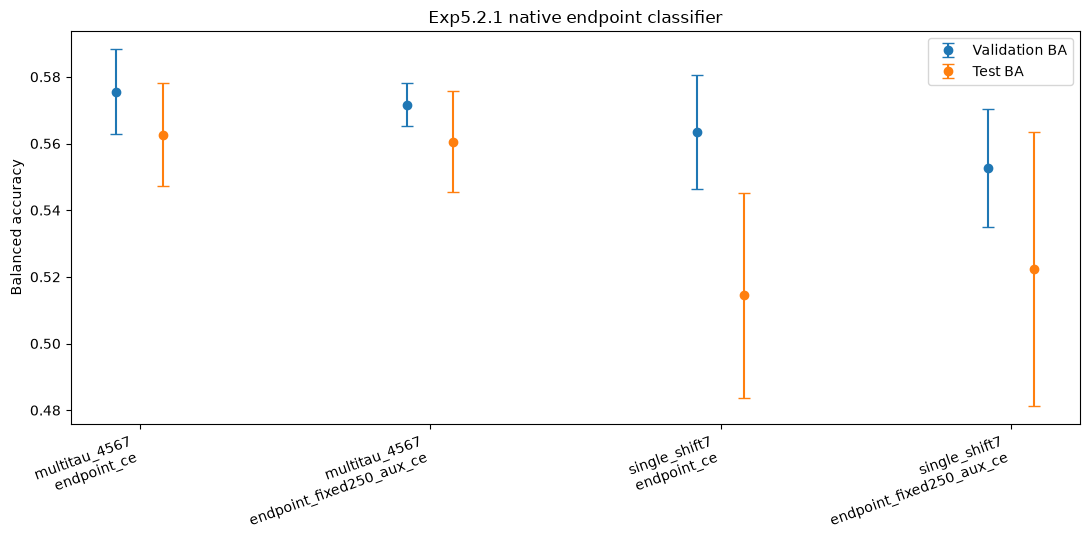

In [5]:
plot_summary = (
    runs.groupby(["memory_mode", "objective"])
    .agg(
        val_mean=("native_val_balanced_accuracy", "mean"),
        val_sd=("native_val_balanced_accuracy", "std"),
        test_mean=("native_test_balanced_accuracy", "mean"),
        test_sd=("native_test_balanced_accuracy", "std"),
    )
    .reset_index()
)
plot_summary["condition"] = plot_summary["memory_mode"] + "\n" + plot_summary["objective"]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(plot_summary))
ax.errorbar(x - 0.08, plot_summary["val_mean"], yerr=plot_summary["val_sd"], fmt="o", capsize=4, label="Validation BA")
ax.errorbar(x + 0.08, plot_summary["test_mean"], yerr=plot_summary["test_sd"], fmt="o", capsize=4, label="Test BA")
ax.set_xticks(x)
ax.set_xticklabels(plot_summary["condition"], rotation=20, ha="right")
ax.set_ylabel("Balanced accuracy")
ax.set_title("Exp5.2.1 native endpoint classifier")
ax.legend()
fig.tight_layout()
plt.show()


## Representation and endpoint-head diagnostics


In [6]:
probe_summary = (
    diagnostic_runs.groupby(["memory_mode", "objective"])
    .agg(
        whole=("hidden_whole_count_test_ba", "mean"),
        fixed250=("hidden_fixed250_ordered_test_ba", "mean"),
        relative10=("hidden_relative10_ordered_test_ba", "mean"),
        uend_probe=("hidden_uend_test_ba", "mean"),
        native=("native_test_balanced_accuracy", "mean"),
        head_gap=("head_utilization_gap", "mean"),
        trajectory_endpoint_gap=("trajectory_endpoint_gap", "mean"),
    )
    .reset_index()
)
probe_summary


,memory_mode,objective,whole,fixed250,relative10,uend_probe,native,head_gap,trajectory_endpoint_gap
0,multitau_4567,endpoint_ce,0.510852,0.581884,0.623565,0.565739,0.562702,0.003037,0.057826
1,multitau_4567,endpoint_fixed250_aux_ce,0.506989,0.566619,0.620289,0.554971,0.560549,-0.005578,0.065318
2,single_shift7,endpoint_ce,0.501930,0.562708,0.632270,0.575831,0.514414,0.061416,0.056439
3,single_shift7,endpoint_fixed250_aux_ce,0.515184,0.588738,0.641427,0.552536,0.522412,0.030123,0.088891


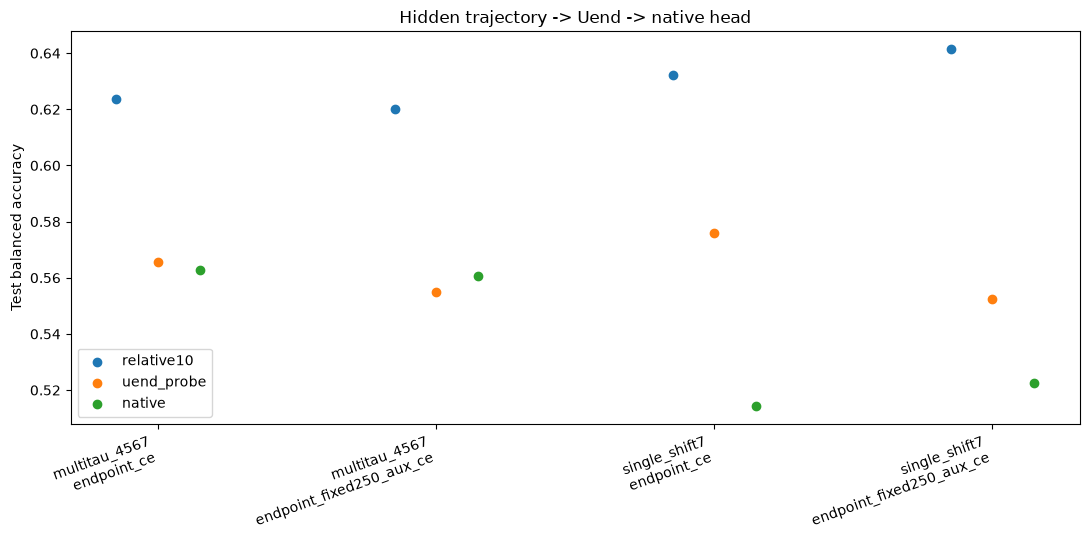

In [7]:
fig, ax = plt.subplots(figsize=(11, 5.5))
labels = [f"{row.memory_mode}\n{row.objective}" for row in probe_summary.itertuples()]
x = np.arange(len(labels))
for metric, offset in [("relative10", -0.15), ("uend_probe", 0.0), ("native", 0.15)]:
    ax.scatter(x + offset, probe_summary[metric], label=metric)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylabel("Test balanced accuracy")
ax.set_title("Hidden trajectory -> Uend -> native head")
ax.legend()
fig.tight_layout()
plt.show()


## Validation learning curves


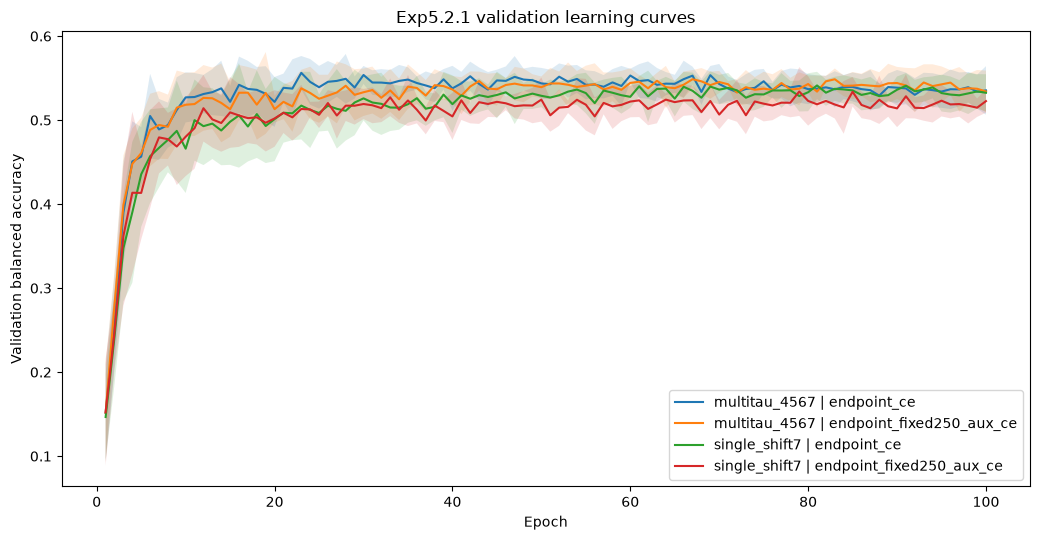

In [8]:
curve = (
    histories.groupby(["memory_mode", "objective", "epoch"])["val_balanced_accuracy"]
    .agg(["mean", "std"])
    .reset_index()
)
fig, ax = plt.subplots(figsize=(10.5, 5.5))
for (memory_mode, objective), group in curve.groupby(["memory_mode", "objective"]):
    group = group.sort_values("epoch")
    label = f"{memory_mode} | {objective}"
    ax.plot(group["epoch"], group["mean"], label=label)
    ax.fill_between(group["epoch"], group["mean"] - group["std"], group["mean"] + group["std"], alpha=0.15)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation balanced accuracy")
ax.set_title("Exp5.2.1 validation learning curves")
ax.legend()
fig.tight_layout()
plt.show()


## Frozen Local reference


In [9]:
local_summary = (
    local_reference.groupby("probe_type")["test_ba"]
    .agg(["mean", "std"])
    .sort_values("mean")
)
local_summary


,mean,std
probe_type,,
local_whole_count,0.543896,0.028094
local_fixed250_ordered,0.625055,0.025606
local_relative10_ordered,0.689499,0.033622
